### 1. Create and train

#### 1.1 Load and reshape MNIST dataset

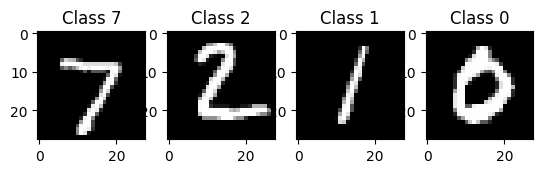

In [13]:
import numpy as np
import tensorflow as tf

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import tf_keras as keras

from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# add a channel dimension as Akida excepts 4-D (num_samples, height, width, channels)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

f, axarr = plt.subplots(1, 4)
for i in range(0, 4):
    axarr[i].imshow(x_test[i].reshape((28, 28)), cmap=cm.Greys_r)
    axarr[i].set_title('Class %d' % y_test[i])
plt.show()


#### 1.2 Model definition

In [14]:
model_keras = keras.models.Sequential([
    keras.layers.Input(shape=(28, 28, 1), name="input", dtype=tf.uint8),
    keras.layers.Rescaling(1. / 255),
    keras.layers.Conv2D(filters=32, kernel_size=3, strides=2),
    keras.layers.BatchNormalization(),
    keras.layers.ReLU(),
    # Separable layer
    keras.layers.DepthwiseConv2D(kernel_size=3, padding='same', strides=2),
    keras.layers.Conv2D(filters=64, kernel_size=1, padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.ReLU(),
    keras.layers.Flatten(),
    keras.layers.Dense(10)
], 'mnistnet')

model_keras.summary()

Model: "mnistnet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 28, 28, 1)         0         
                                                                 
 conv2d (Conv2D)             (None, 13, 13, 32)        320       
                                                                 
 batch_normalization (Batch  (None, 13, 13, 32)        128       
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 13, 13, 32)        0         
                                                                 
 depthwise_conv2d (Depthwis  (None, 7, 7, 32)          320       
 eConv2D)                                                        
                                                                 
 conv2d_1 (Conv2D)           (None, 7, 7, 64)          211

#### 1.3 Model training

In [17]:
model_keras.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

_ = model_keras.fit(x_train, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1688/1688 [==============================] - 25s 14ms/step - loss: 0.1706 - accuracy: 0.9481 - val_loss: 0.0764 - val_accuracy: 0.9802
Epoch 2/10
1688/1688 [==============================] - 23s 14ms/step - loss: 0.0716 - accuracy: 0.9775 - val_loss: 0.0812 - val_accuracy: 0.9783
Epoch 3/10
1688/1688 [==============================] - 23s 14ms/step - loss: 0.0540 - accuracy: 0.9831 - val_loss: 0.0563 - val_accuracy: 0.9837
Epoch 4/10
1688/1688 [==============================] - 22s 13ms/step - loss: 0.0409 - accuracy: 0.9869 - val_loss: 0.0750 - val_accuracy: 0.9770
Epoch 5/10
1688/1688 [==============================] - 23s 14ms/step - loss: 0.0341 - accuracy: 0.9888 - val_loss: 0.0561 - val_accuracy: 0.9863
Epoch 6/10
1688/1688 [==============================] - 23s 14ms/step - loss: 0.0278 - accuracy: 0.9910 - val_loss: 0.0510 - val_accuracy: 0.9885
Epoch 7/10
1688/1688 [==============================] - 22s 13ms/step - loss: 0.0246 - accuracy: 0.9918 - val_loss: 0.0560 -

In [18]:
score = model_keras.evaluate(x_test, y_test, verbose=0)
print("Test accuracy: ", score)

Test accuracy:  [0.05408063530921936, 0.9842000007629395]


### 2. Quantize

#### 2.1 8-bit Quantization

In [19]:
from quantizeml.models import quantize, QuantizationParams

qparams = QuantizationParams(input_weight_bits=8, weight_bits=8, activation_bits=8)
model_quantized = quantize(model_keras, qparams=qparams)

/usr/local/lib/python3.12/dist-packages/quantizeml/models/quantize.py:577: UserWarning: Quantizing per-axis with random calibration samples is not accurate. Set QuantizationParams.per_tensor_activations=True when calibrating with random samples. Continuing execution.
  warnings.warn("Quantizing per-axis with random calibration samples is not accurate. "


1024/1024 [==============================] - 3s 2ms/step


In [20]:
model_quantized.summary()

Model: "mnistnet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 28, 28, 1)]       0         
                                                                 
 rescaling (QuantizedRescal  (None, 28, 28, 1)         0         
 ing)                                                            
                                                                 
 conv2d (QuantizedConv2D)    (None, 13, 13, 32)        320       
                                                                 
 re_lu (QuantizedReLU)       (None, 13, 13, 32)        64        
                                                                 
 depthwise_conv2d (Quantize  (None, 7, 7, 32)          384       
 dDepthwiseConv2D)                                               
                                                                 
 conv2d_1 (QuantizedConv2D)  (None, 7, 7, 64)          211

In [21]:
def compile_eval(model):
    model.compile(metrics=['accuracy'])
    return model.evaluate(x_test, y_test, verbose=0)[1]

print("Model accuracy after 8-bit quantization: ", compile_eval(model_quantized))

Model accuracy after quantization:  0.9786999821662903


#### 2.2 Calibration

In [22]:
model_quantized = quantize(model_keras, qparams=qparams, samples=x_train, num_samples=1024, batch_size=100, epochs=2)

11/11 [==============================] - 0s 9ms/step


In [23]:
print("Accuracy after calibration: ", compile_eval(model_quantized))

Accuracy after calibration:  0.9824000000953674


#### 2.3 4-bit Quantization

In [24]:
qparams = QuantizationParams(input_weight_bits=8, weight_bits=4, activation_bits=4)
model_quantized = quantize(model_keras, qparams=qparams, samples=x_train, num_samples=1024, batch_size=100, epochs=2)

11/11 [==============================] - 0s 12ms/step


In [25]:
print("Accuracy after 4-bit quantization: ", compile_eval(model_quantized))

Accuracy after 4-bit quantization:  0.9812999963760376


#### 2.4 Fine Tuning (Quantization Aware Tuning)

In [26]:
model_quantized.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

model_quantized.fit(x_train, y_train, epochs=5, validation_split=0.1)

Epoch 1/5
1688/1688 [==============================] - 38s 20ms/step - loss: 0.0168 - accuracy: 0.9951 - val_loss: 0.0485 - val_accuracy: 0.9865
Epoch 2/5
1688/1688 [==============================] - 30s 18ms/step - loss: 0.0132 - accuracy: 0.9961 - val_loss: 0.0467 - val_accuracy: 0.9872
Epoch 3/5
1688/1688 [==============================] - 30s 18ms/step - loss: 0.0119 - accuracy: 0.9965 - val_loss: 0.0463 - val_accuracy: 0.9870
Epoch 4/5
1688/1688 [==============================] - 31s 19ms/step - loss: 0.0108 - accuracy: 0.9970 - val_loss: 0.0489 - val_accuracy: 0.9865
Epoch 5/5
1688/1688 [==============================] - 31s 18ms/step - loss: 0.0101 - accuracy: 0.9974 - val_loss: 0.0500 - val_accuracy: 0.9882


In [27]:
score = model_quantized.evaluate(x_test, y_test, verbose=0)
print("Accuracy score after fine tuning: ", score[1])

Accuracy score after fine tuning:  0.9861999750137329


### 3. Convert

#### 3.1 Akida model

In [ ]:
from cnn2snn import convert # type: ignore

model_akida = convert(model_quantized)
model_akida.summary()

                Model Summary                 
______________________________________________
Input shape  Output shape  Sequences  Layers
[28, 28, 1]  [1, 1, 10]    1          5     
______________________________________________

__________________________________________________________________
Layer (type)                        Output shape  Kernel shape  

=============== SW/conv2d-dequantizer_2 (Software) ===============

conv2d (InputConv2D)                [13, 13, 32]  (3, 3, 1, 32) 
__________________________________________________________________
depthwise_conv2d (DepthwiseConv2D)  [7, 7, 32]    (3, 3, 32, 1) 
__________________________________________________________________
conv2d_1 (Conv2D)                   [7, 7, 64]    (1, 1, 32, 64)
__________________________________________________________________
dense (Dense1D)                     [1, 1, 10]    (3136, 10)    
__________________________________________________________________
dequantizer_2 (Dequantizer)         [1,

In [35]:
score = model_akida.evaluate(x_test, y_test.astype(np.int32))
print("Accuracy for akida model: ", score)

assert score > 0.96

Accuracy for akida model:  0.9868000149726868


#### 3.3 Show prediction for a single image

In [39]:
sample_image = 1
image = x_test[sample_image]
outputs = model_akida.predict(image.reshape(1, 28, 28, 1))
print('Input label: %i' % y_test[sample_image])
print(outputs)

Input label: 2
[[[[ -5.0531096  -2.9581223   6.8811235  -8.313115  -10.873457
    -10.993806   -1.0338968 -16.59948    -7.47479   -11.685083 ]]]]


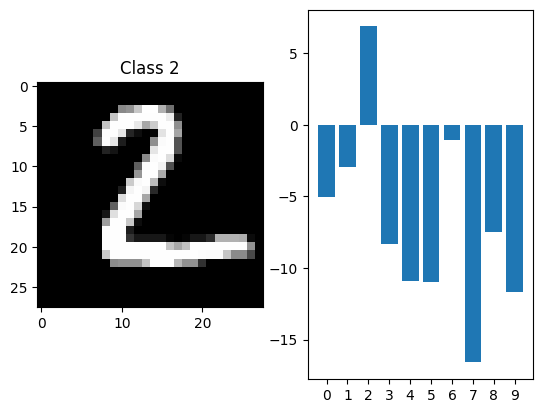

[ -5.0531096  -2.9581223   6.8811235  -8.313115  -10.873457  -10.993806
  -1.0338968 -16.59948    -7.47479   -11.685083 ]


In [40]:
f, axarr = plt.subplots(1, 2)
axarr[0].imshow(x_test[sample_image].reshape((28, 28)), cmap=cm.Greys_r)
axarr[0].set_title('Class %d' % y_test[sample_image])
axarr[1].bar(range(10), outputs.squeeze())
axarr[1].set_xticks(range(10))
plt.show()

print(outputs.squeeze())